In [ ]:
from magsim import TimeSeriesSimulator, SimulatorConfig, NoiseModel, SourceType, SensorArrayLoader

In [ ]:
import numpy as np

sensors_xyz, sensor_metadata = SensorArrayLoader.from_fwf('L058.txt')
print(f"Loaded {len(sensors_xyz)} sensors")
print(f"\nFirst 5 rows (preview):")
print(sensors_xyz[:5])

In [ ]:
if __name__ == "__main__":

    config = SimulatorConfig(
        sensor_positions=sensors_xyz,
        sensor_metadata=sensor_metadata,
        magnetic_constant=1.0,           # normalized units
        default_source_bounds=(-3, 3),
        default_moment_range=(0.5, 2.0),
        noise_std=0.05,
        random_seed=42,
    )

    sim = TimeSeriesSimulator(sensors_xyz, config)

    print("\nGenerating training data...")
    X_train, y_train = sim.generate_batch(n_samples=10000, add_noise_flag=True)

    print("Generating dev data...")
    X_dev, y_dev = sim.generate_batch(n_samples=2000, add_noise_flag=True)

    print("Generating validation data...")
    X_val, y_val = sim.generate_batch(n_samples=2000, add_noise_flag=True)

    stats = sim.get_data_statistics(X_train, y_train)
    print(f"\nData Statistics:")
    print(f"  Input shape:  {X_train.shape}")
    print(f"  Output shape: {y_train.shape}")
    print(f"  Output mean:  {stats['output']['mean']}")

    sim.save_dataset(X_train, y_train, "magnetometer_training_data.npz")
    sim.save_dataset(X_dev,   y_dev,   "magnetometer_dev_data.npz")
    sim.save_dataset(X_val,   y_val,   "magnetometer_val_data.npz")

    print("\nGenerating time series data...")
    def circular_trajectory(t):
        radius = 2.0
        return np.array([radius * np.cos(t), radius * np.sin(t), np.sin(2 * t)])

    X_series, y_series = sim.generate_time_series(
        n_timesteps=7201,
        trajectory_func=circular_trajectory,
        dt=1,
        add_noise_flag=True,
    )
    print(f"  Time series shape: {X_series.shape}")
    print("\nSimulator ready.")

<Axes3D: title={'center': 'Sensor Array Layout (29 Sensors)'}, xlabel='X (m)', ylabel='Y (m)', zlabel='Z (m)'>

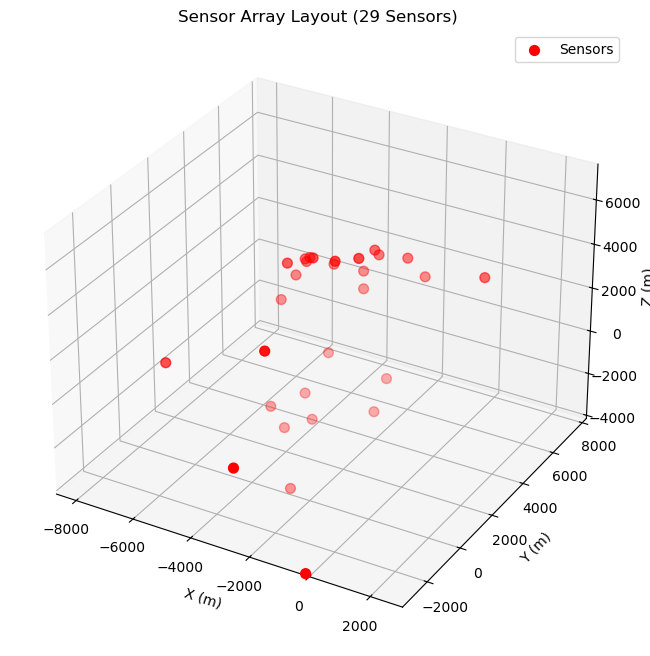

In [12]:
sim.visualize_sensor_array()